In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchsummary import summary

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

In [ ]:
# the champion in image compression into low-dimensional features is the convolutional variational autoencoder
# it can encode images from the MNIST dataset into just two features.
# download variational autoencoder
!wget http://agentspace.org/download/mnist_cvae_encoder.pth
!wget http://agentspace.org/download/mnist_cvae_decoder.pth

In [ ]:
# load variational autoencoder
encoder = torch.load('mnist_cvae_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('mnist_cvae_decoder.pth', weights_only=False, map_location=device)

In [ ]:
encoder.eval()

In [ ]:
decoder.eval()

In [ ]:
# test dataloader
batch_size = 256
test_loader = DataLoader(datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor()), batch_size=batch_size, shuffle=False)

In [ ]:
# get few samples
test_iter = iter(test_loader)
x_sample = next(test_iter)[0][0:10].to(device)
print(x_sample.shape)

In [ ]:
# encode and decode
y_sample = decoder(encoder(x_sample))
print(y_sample.shape)

In [ ]:
# show the comparison
plt.figure(figsize=(20, 4))
for i in range(10):
    input_img = (x_sample[i].squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
    plt.subplot(2, 10, i+1)
    plt.imshow(input_img, cmap='gray')
    plt.axis('off')
    output_img = (y_sample[i].squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
    plt.subplot(2, 10, i+1+10)
    plt.imshow(output_img, cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
feature_vectors = []
categories = []
for batch, (x_test, y_test) in enumerate(test_loader):
    feature_vector = encoder(x_test.to(device))
    feature_vectors.append(feature_vector)
    categories += [ category.item() for category in y_test ]
feature_vectors = torch.cat(feature_vectors, dim=0)
print(feature_vectors.shape)

In [ ]:
print(feature_vectors[0:10])

In [ ]:
categories[0:10]

In [ ]:
points = feature_vectors.detach().cpu().numpy()
print(points.shape)

In [ ]:
# How to put dots on image
size = 10
num_dots = 100

# 10 different colors
colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'lime', 'white']

# Generate random coordinates and colors
x = np.random.rand(num_dots) * size
y = np.random.rand(num_dots) * size
dot_colors = np.random.choice(colors, num_dots)

# Create black background figure
fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

# Plot the dots
ax.scatter(x, y, c=dot_colors, s=2)

# Set limits and remove axes
ax.set_xlim(0, size)
ax.set_ylim(0, size)
ax.axis('off')

plt.show()

Provide code that visualize the testing dataset projected into the latent space. It looks like
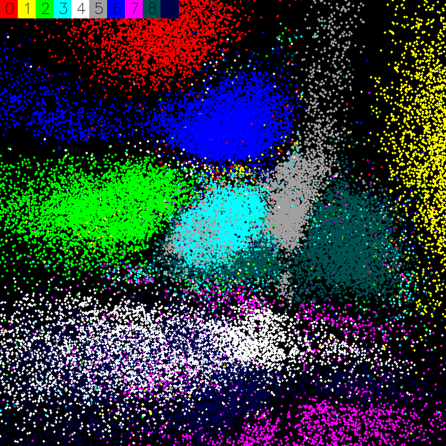

In [ ]:
# How to put rendered images on the common background
def render(digit):
    img = np.zeros((28, 28), dtype=np.uint8)
    cv2.putText(img, str(digit), (6, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.9, 255, 2)
    return img

# Create a grid image: 10 rows (digits 0–9), each row with 10 copies of the same digit
rows = []
for digit in range(10):
    row = np.hstack([render(digit) for _ in range(10)])  # 10 copies horizontally
    rows.append(row)

grid_img = np.vstack(rows)  # stack all rows vertically

plt.figure(figsize=(10, 10))
plt.imshow(grid_img, cmap='gray')
plt.axis('off')
plt.show()

Provide code that visualize what the latent space generates. It looks like
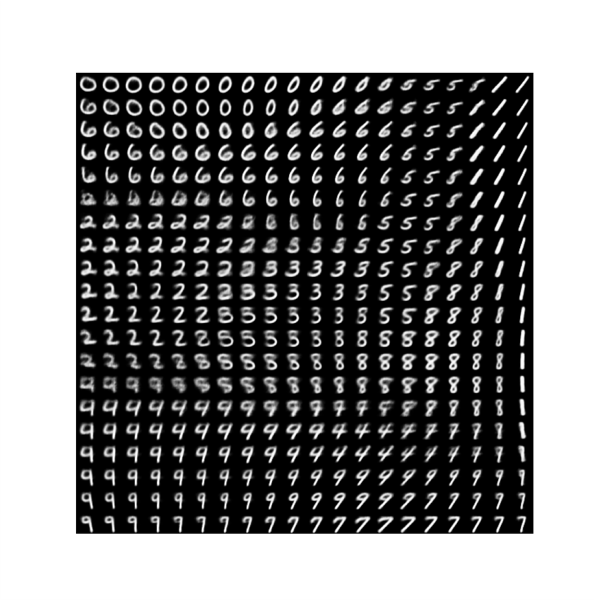

In [ ]:
from google.colab import files
files.download('dataset_in_the_latent_space.png')
files.download('generative_latent_space.png')